# War-Period Visualizations: OHLC & Returns
**6 charts from `ohlc_clean.xls` + `ohlc_processed.xls`**  
Period: Mar 4 – Apr 13, 2026 | 12 sectors | 47 NSE stocks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

returns = pd.read_csv('ohlc_processed.xls', parse_dates=['date'], index_col='date')
ohlc    = pd.read_csv('ohlc_clean.xls',     parse_dates=['date'])

TICKER_SECTOR = {
    'HINDPETRO.NS':  'Oil & Gas — OMCs',   'BPCL.NS':       'Oil & Gas — OMCs',
    'IOC.NS':        'Oil & Gas — OMCs',   'IGL.NS':        'Oil & Gas — OMCs',
    'MGL.NS':        'Oil & Gas — OMCs',   'GUJARATGAS.NS': 'Oil & Gas — OMCs',
    'ONGC.NS':       'Oil & Gas — Upstream', 'OIL.NS':      'Oil & Gas — Upstream',
    'VEDL.NS':       'Oil & Gas — Upstream',
    'HAL.NS': 'Defence', 'BDL.NS': 'Defence', 'BEL.NS': 'Defence', 'BEML.NS': 'Defence',
    'MAZDOCK.NS': 'Defence', 'GRSE.NS': 'Defence', 'COCHINSHIP.NS': 'Defence', 'DATAPATTNS.NS': 'Defence',
    'INDIGO.NS': 'Aviation',
    'ASIANPAINT.NS': 'Paints', 'BERGEPAINT.NS': 'Paints', 'KANSAINER.NS': 'Paints', 'INDIGOPNTS.NS': 'Paints',
    'MRF.NS': 'Tyres', 'APOLLOTYRE.NS': 'Tyres', 'CEATLTD.NS': 'Tyres', 'BALKRISIND.NS': 'Tyres',
    'SUNPHARMA.NS': 'Pharma', 'DRREDDY.NS': 'Pharma', 'DIVISLAB.NS': 'Pharma', 'CIPLA.NS': 'Pharma',
    'ADANIPORTS.NS': 'Shipping & Ports', 'SCI.NS': 'Shipping & Ports',
    'GESHIP.NS': 'Shipping & Ports', 'ESSARSHPNG.NS': 'Shipping & Ports',
    'LT.NS': 'Capital Goods', 'THERMAX.NS': 'Capital Goods', 'KEC.NS': 'Capital Goods',
    'TITAN.NS': 'Gold-Linked', 'KALYANKJIL.NS': 'Gold-Linked',
    'MUTHOOTFIN.NS': 'Gold-Linked', 'MANAPPURAM.NS': 'Gold-Linked',
    'COROMANDEL.NS': 'Chemicals & Fertilisers', 'DEEPAKNTR.NS': 'Chemicals & Fertilisers',
    'GNFC.NS': 'Chemicals & Fertilisers', 'TATACHEM.NS': 'Chemicals & Fertilisers',
    'INFY.NS': 'IT & Tech', 'WIPRO.NS': 'IT & Tech', 'HCLTECH.NS': 'IT & Tech',
}

SECTOR_ORDER = [
    'Oil & Gas — OMCs', 'Oil & Gas — Upstream', 'Aviation', 'Shipping & Ports',
    'Defence', 'Capital Goods', 'Gold-Linked', 'Chemicals & Fertilisers',
    'Tyres', 'Paints', 'Pharma', 'IT & Tech',
]

SHORT_SEC = {
    'Oil & Gas — OMCs':        'Oil OMCs',
    'Oil & Gas — Upstream':    'Oil Upstream',
    'Aviation':                  'Aviation',
    'Shipping & Ports':          'Shipping',
    'Defence':                   'Defence',
    'Capital Goods':             'Cap Goods',
    'Gold-Linked':               'Gold',
    'Chemicals & Fertilisers':   'Chem & Fert',
    'Tyres':                     'Tyres',
    'Paints':                    'Paints',
    'Pharma':                    'Pharma',
    'IT & Tech':                 'IT & Tech',
}

meta = pd.DataFrame(list(TICKER_SECTOR.items()), columns=['ticker', 'sector']).set_index('ticker')

sector_ret = {}
for sec in SECTOR_ORDER:
    tickers = meta[meta['sector'] == sec].index.tolist()
    avail = [t for t in tickers if t in returns.columns]
    if avail:
        sector_ret[sec] = returns[avail].mean(axis=1)
S = pd.DataFrame(sector_ret)

EVENTS = {
    pd.Timestamp('2026-04-01'): 'Defence Shock',
    pd.Timestamp('2026-04-10'): 'Essar Shock',
}

SEC_COLORS = dict(zip(SECTOR_ORDER, plt.cm.tab20.colors[:12]))

print(f'Returns: {returns.shape} | OHLC: {ohlc.shape} | Sector returns: {S.shape}')

Returns: (26, 47) | OHLC: (1269, 9) | Sector returns: (26, 12)


## Viz 1 — Cumulative Sector Returns (Line Chart)
Shows the full war-period narrative: which sectors accumulated gains vs losses.  
Defence spikes on Apr 1 (GRSE +19.6%, Mazdock +12.3%, CochinShip +12.2%).

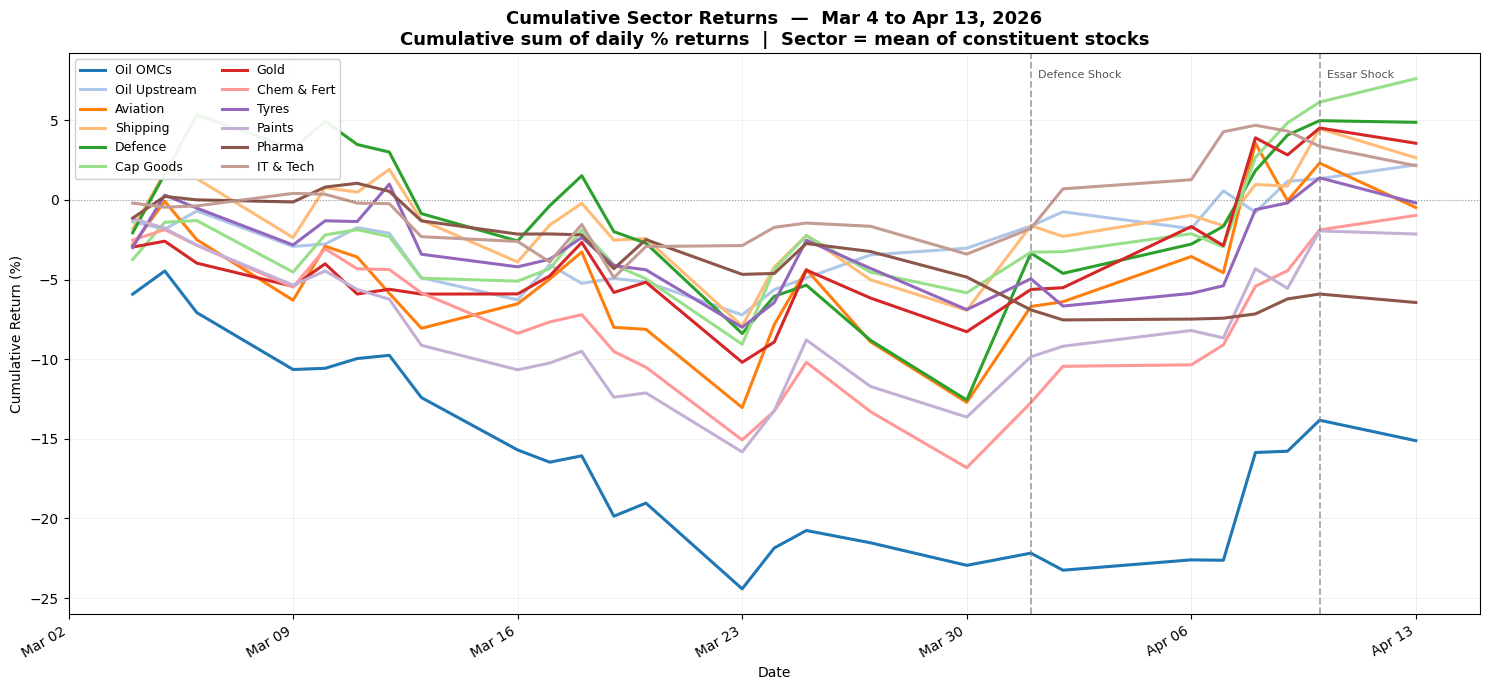

In [2]:
cumul = S.cumsum()

fig, ax = plt.subplots(figsize=(15, 7))
for sec in SECTOR_ORDER:
    if sec in cumul.columns:
        ax.plot(cumul.index, cumul[sec], color=SEC_COLORS[sec], linewidth=2.2,
                label=SHORT_SEC[sec])

for dt, label in EVENTS.items():
    ax.axvline(dt, color='gray', linestyle='--', alpha=0.7, linewidth=1.3)
    ax.text(dt, 0.97, f'  {label}', fontsize=8, color='#555555',
            va='top', transform=ax.get_xaxis_transform())

ax.axhline(0, color='black', linewidth=0.8, alpha=0.35, linestyle=':')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_title(
    'Cumulative Sector Returns  \u2014  Mar 4 to Apr 13, 2026\n'
    'Cumulative sum of daily % returns  |  Sector = mean of constituent stocks',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Cumulative Return (%)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.92)
ax.grid(True, alpha=0.25, linewidth=0.5)
plt.tight_layout()
plt.savefig('viz1_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## Viz 2 — Sector × Date Daily Return Heatmap
Day-by-day sector return map. Reveals which sectors were hit/boosted on specific trading days.  
Gold event columns highlight the two shock dates.

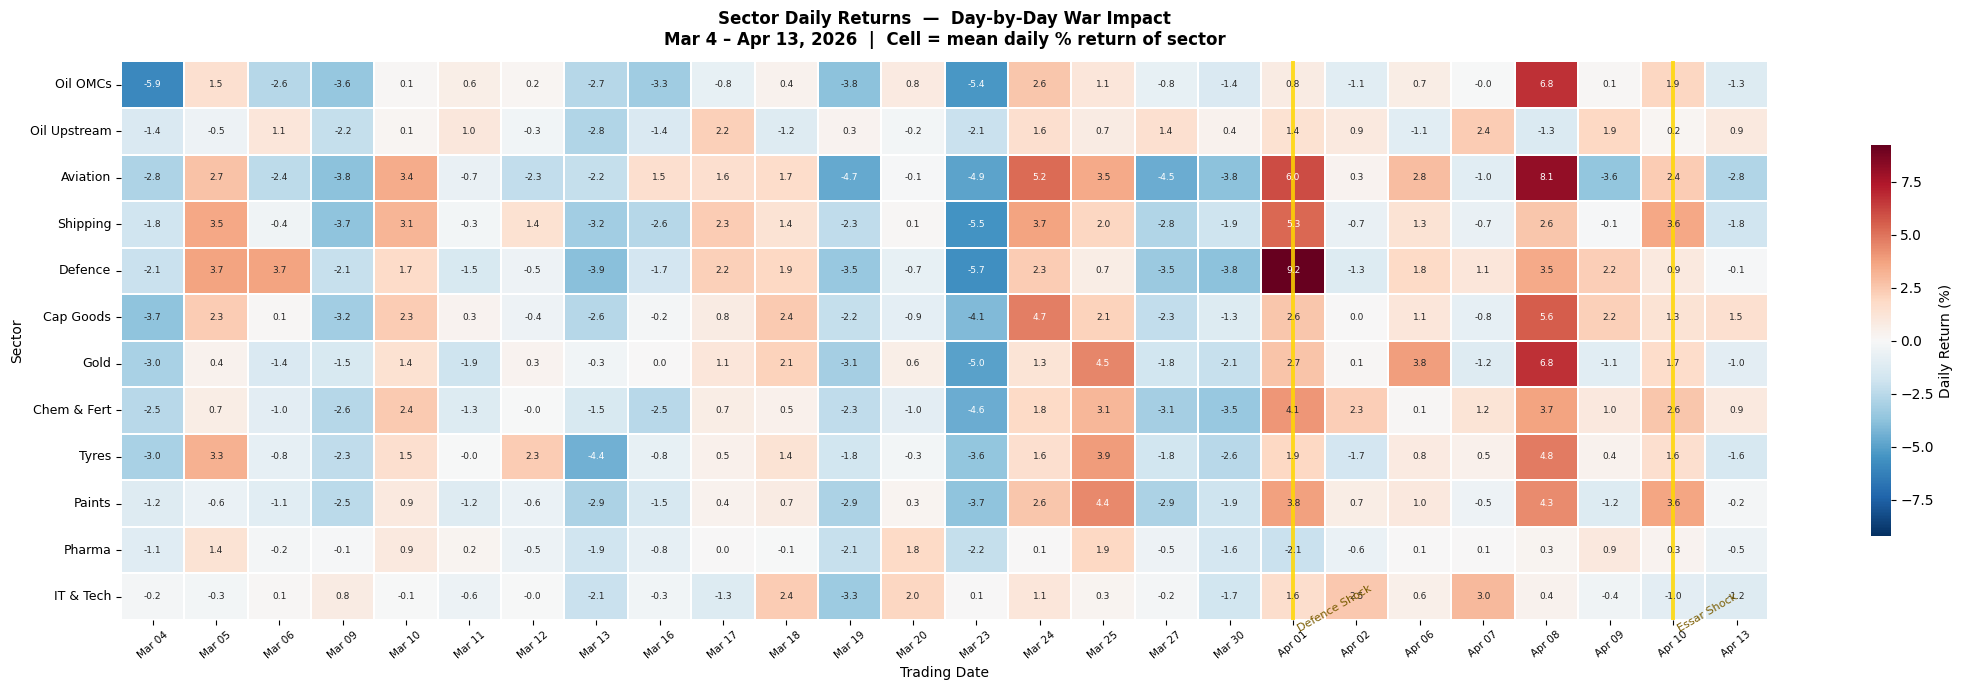

In [3]:
S_heat = S[[s for s in SECTOR_ORDER if s in S.columns]].T
S_heat.index = [SHORT_SEC[s] for s in S_heat.index]
date_labels  = [d.strftime('%b %d') for d in S.index]
vmax = max(abs(S_heat.min().min()), abs(S_heat.max().max()))

fig, ax = plt.subplots(figsize=(22, 7))
sns.heatmap(
    S_heat,
    cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
    annot=True, fmt='.1f', annot_kws={'size': 6.5},
    linewidths=0.3, linecolor='white',
    xticklabels=date_labels, ax=ax,
    cbar_kws={'label': 'Daily Return (%)', 'shrink': 0.7},
)

for dt, label in EVENTS.items():
    if dt in S.index:
        col_idx = list(S.index).index(dt) + 0.5
        ax.axvline(col_idx, color='gold', linewidth=2.8, alpha=0.85)
        ax.text(col_idx + 0.05, len(S_heat) + 0.25, label,
                fontsize=8, color='#7a5c00', rotation=30, ha='left')

ax.set_title(
    'Sector Daily Returns  \u2014  Day-by-Day War Impact\n'
    'Mar 4 \u2013 Apr 13, 2026  |  Cell = mean daily % return of sector',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Trading Date', fontsize=10)
ax.set_ylabel('Sector', fontsize=10)
ax.tick_params(axis='x', rotation=40, labelsize=7.5)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('viz2_sector_return_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Viz 3 — Volume Anomaly Heatmap
Z-scored trading volume per ticker, aggregated to sector means.  
Identifies unusual market attention — high z-score = abnormally high trading activity that day.

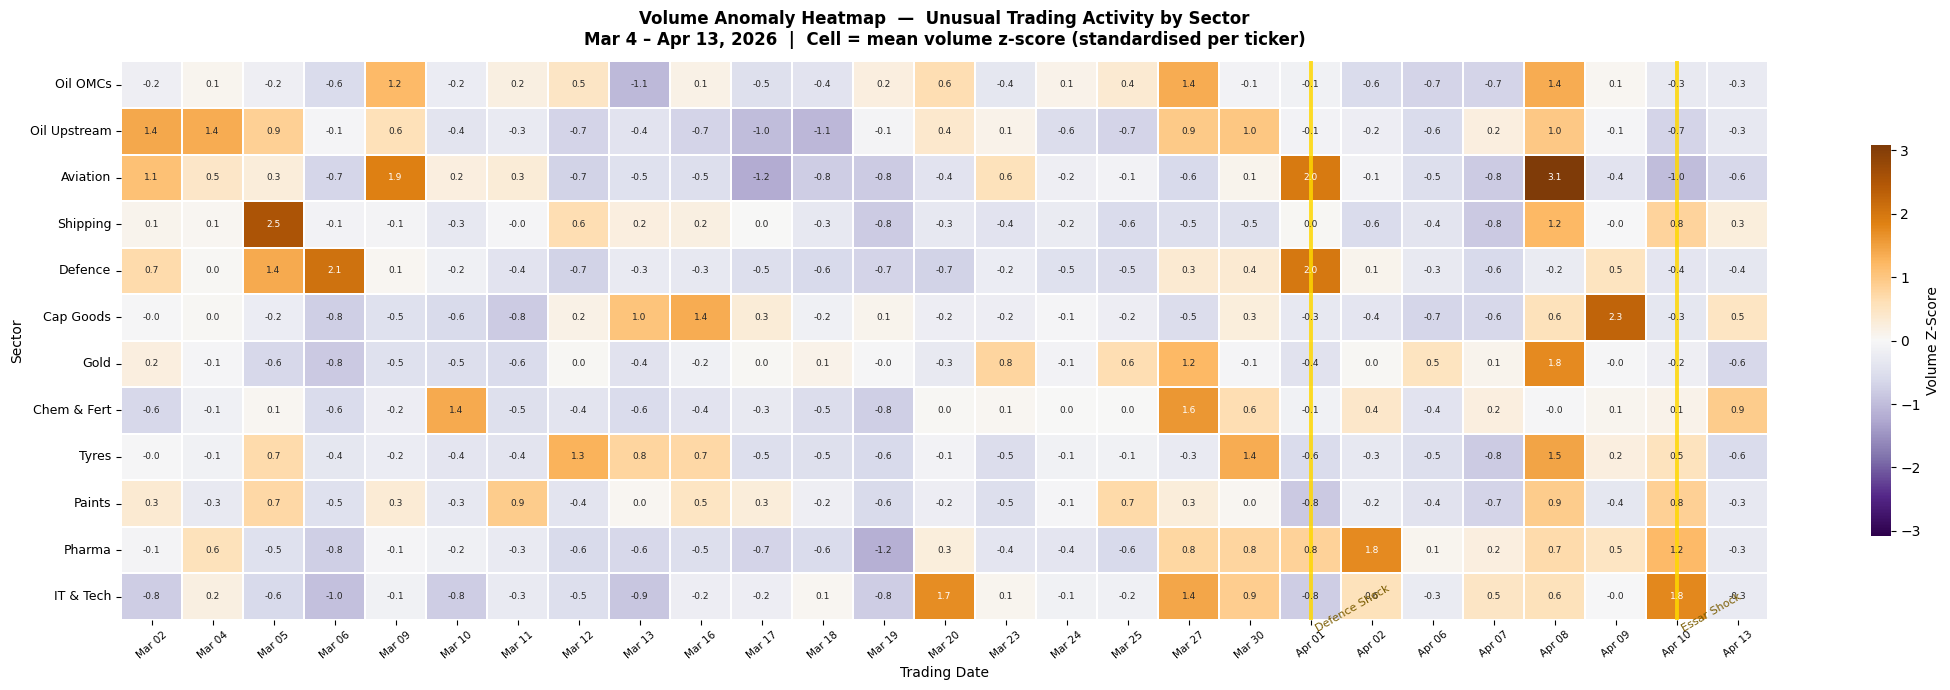

In [4]:
ohlc['vol_z'] = ohlc.groupby('ticker')['volume'].transform(
    lambda x: (x - x.mean()) / max(x.std(), 1e-9)
)

vol_heat = (
    ohlc.groupby(['date', 'sector'])['vol_z'].mean()
    .unstack()
    .reindex(columns=SECTOR_ORDER)
)
vol_heat_T = vol_heat.T
vol_heat_T.index = [SHORT_SEC.get(s, s) for s in vol_heat_T.index]
date_labels_v = [d.strftime('%b %d') for d in vol_heat.index]
vmax_v = max(abs(vol_heat_T.min().min()), abs(vol_heat_T.max().max()))

fig, ax = plt.subplots(figsize=(22, 7))
sns.heatmap(
    vol_heat_T,
    cmap='PuOr_r', center=0, vmin=-vmax_v, vmax=vmax_v,
    annot=True, fmt='.1f', annot_kws={'size': 6.5},
    linewidths=0.3, linecolor='white',
    xticklabels=date_labels_v, ax=ax,
    cbar_kws={'label': 'Volume Z-Score', 'shrink': 0.7},
)

for dt, label in EVENTS.items():
    if dt in vol_heat.index:
        col_idx = list(vol_heat.index).index(dt) + 0.5
        ax.axvline(col_idx, color='gold', linewidth=2.8, alpha=0.85)
        ax.text(col_idx + 0.05, len(vol_heat_T) + 0.25, label,
                fontsize=8, color='#7a5c00', rotation=30, ha='left')

ax.set_title(
    'Volume Anomaly Heatmap  —  Unusual Trading Activity by Sector\n'
    'Mar 4 – Apr 13, 2026  |  Cell = mean volume z-score (standardised per ticker)',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlabel('Trading Date', fontsize=10)
ax.set_ylabel('Sector', fontsize=10)
ax.tick_params(axis='x', rotation=40, labelsize=7.5)
ax.tick_params(axis='y', labelsize=9, rotation=0)
plt.tight_layout()
plt.savefig('viz3_volume_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()

## Viz 4 — Intraday Range vs. Daily Return (Scatter)
Uses the ‘within-day’ OHLC data: intraday range = (High − Low) / Close × 100.  
Plots it against the close-to-close daily return to reveal days where stocks moved wildly *within* the session  
vs days with large *committed* directional moves. Shock stocks annotated.

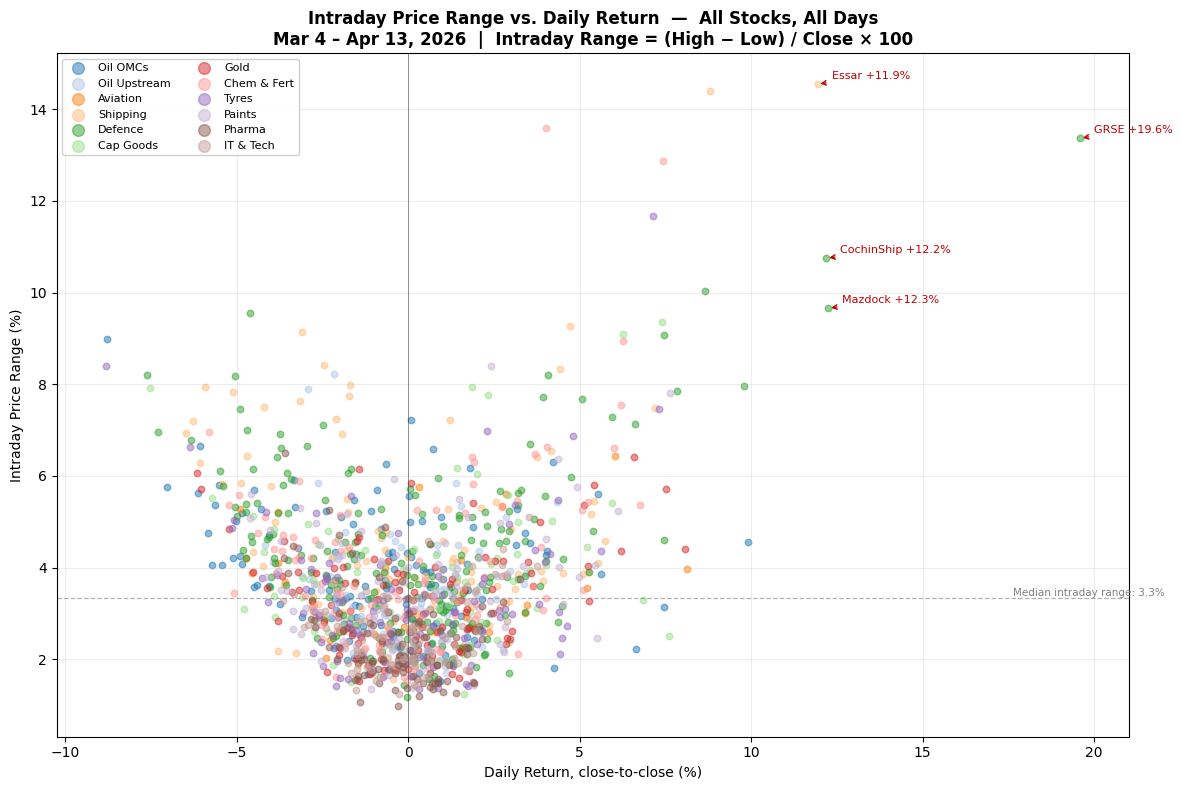

In [5]:
ohlc['intraday_pct'] = (ohlc['high'] - ohlc['low']) / ohlc['close'] * 100

ret_long = returns.reset_index().melt(id_vars='date', var_name='ticker', value_name='daily_ret')
scatter_df = (
    ohlc[['date', 'ticker', 'sector', 'intraday_pct']]
    .merge(ret_long, on=['date', 'ticker'])
    .dropna()
)

fig, ax = plt.subplots(figsize=(12, 8))
for sec in SECTOR_ORDER:
    sub = scatter_df[scatter_df['sector'] == sec]
    ax.scatter(sub['daily_ret'], sub['intraday_pct'],
               color=SEC_COLORS[sec], alpha=0.5, s=22, label=SHORT_SEC[sec])

SHOCKS = [
    ('GRSE.NS',       '2026-04-01', 'GRSE +19.6%'),
    ('MAZDOCK.NS',    '2026-04-01', 'Mazdock +12.3%'),
    ('COCHINSHIP.NS', '2026-04-01', 'CochinShip +12.2%'),
    ('ESSARSHPNG.NS', '2026-04-10', 'Essar +11.9%'),
]
for ticker, date_str, label in SHOCKS:
    row = scatter_df[
        (scatter_df['ticker'] == ticker) &
        (scatter_df['date'] == pd.Timestamp(date_str))
    ]
    if not row.empty:
        ax.annotate(
            label,
            xy=(row['daily_ret'].values[0], row['intraday_pct'].values[0]),
            xytext=(10, 4), textcoords='offset points',
            fontsize=8, color='#c00000',
            arrowprops=dict(arrowstyle='->', color='#c00000', lw=1),
        )

med_range = scatter_df['intraday_pct'].median()
ax.axhline(med_range, color='gray', linewidth=0.9, linestyle='--', alpha=0.6)
ax.text(scatter_df['daily_ret'].max() * 0.9, med_range + 0.05,
        f'Median intraday range: {med_range:.1f}%', fontsize=7.5, color='gray')
ax.axvline(0, color='black', linewidth=0.7, alpha=0.4)

ax.set_title(
    'Intraday Price Range vs. Daily Return  \u2014  All Stocks, All Days\n'
    'Mar 4 \u2013 Apr 13, 2026  |  Intraday Range = (High \u2212 Low) / Close \u00d7 100',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Daily Return, close-to-close (%)', fontsize=10)
ax.set_ylabel('Intraday Price Range (%)', fontsize=10)
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.92, markerscale=1.8)
ax.grid(True, alpha=0.22)
plt.tight_layout()
plt.savefig('viz4_intraday_vs_return.png', dpi=150, bbox_inches='tight')
plt.show()

## Viz 5 — Sector Return Correlation Matrix
Pearson r between sector daily returns over 26 trading days.  
High r = sectors moved together (systemic). Near-zero or negative = decoupled / defensive.

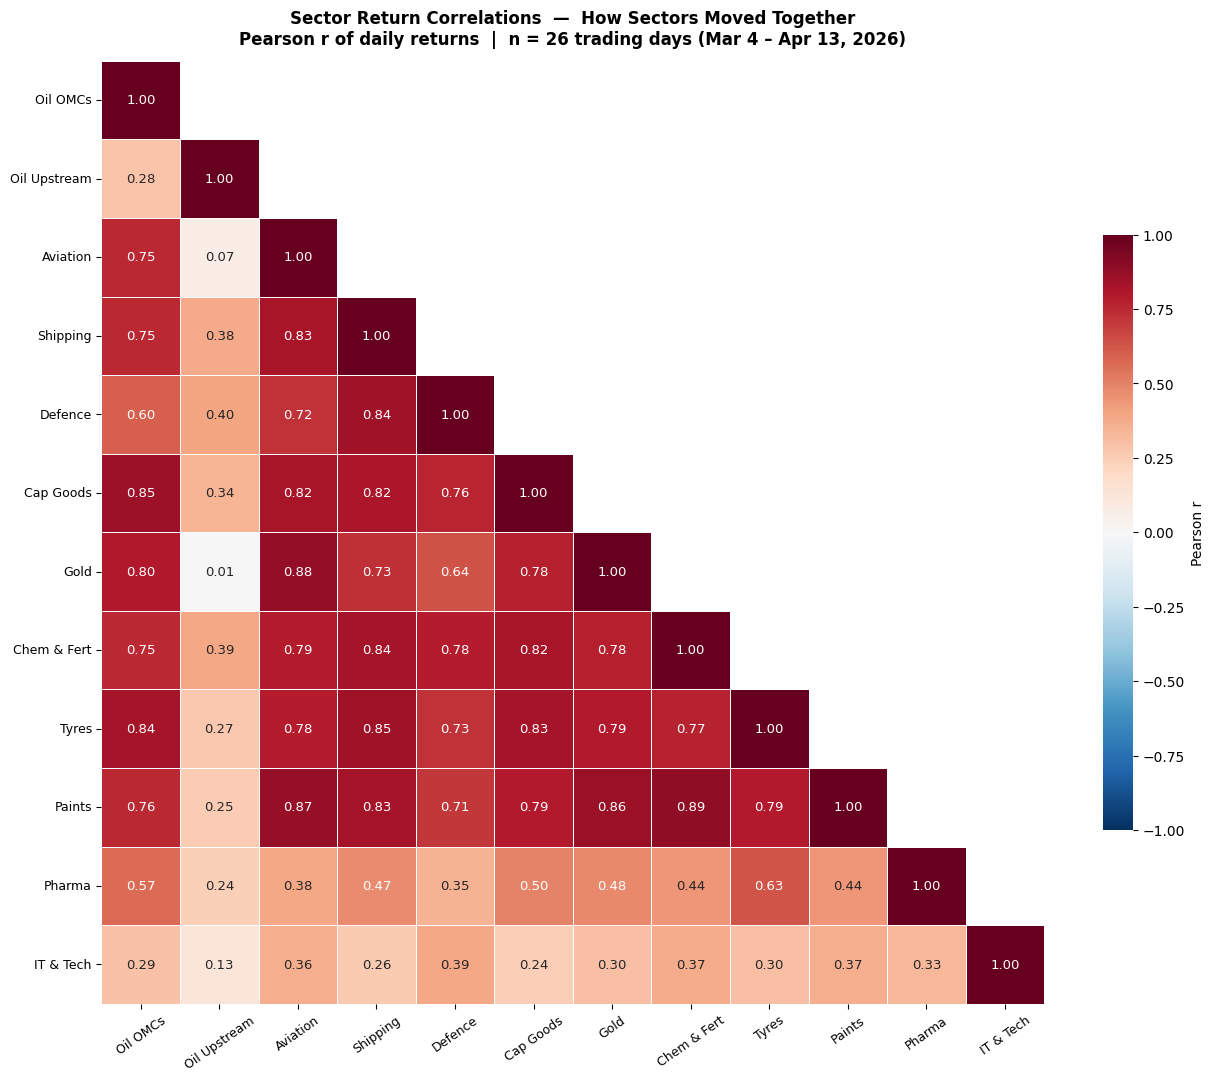

In [6]:
sec_corr = S.corr()
labels   = [SHORT_SEC.get(s, s) for s in sec_corr.index]
sec_corr_disp = sec_corr.copy()
sec_corr_disp.index   = labels
sec_corr_disp.columns = labels

mask = np.triu(np.ones_like(sec_corr_disp, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    sec_corr_disp,
    mask=mask,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9.5},
    linewidths=0.5, linecolor='white',
    ax=ax, square=True,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.6},
)

ax.set_title(
    'Sector Return Correlations  \u2014  How Sectors Moved Together\n'
    'Pearson r of daily returns  |  n = 26 trading days (Mar 4 \u2013 Apr 13, 2026)',
    fontsize=12, fontweight='bold', pad=12
)
ax.tick_params(axis='x', rotation=35, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('viz5_sector_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## Viz 6 — Return Distribution by Sector (Violin Plot)
Full distribution of daily returns for every stock-day in each sector.  
Wide violin = high variance. Fat upper tail in Defence from the 3 shock days. Annotates all 4 outlier events.

C:\Users\kabik\AppData\Local\Temp\ipykernel_27024\107386666.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


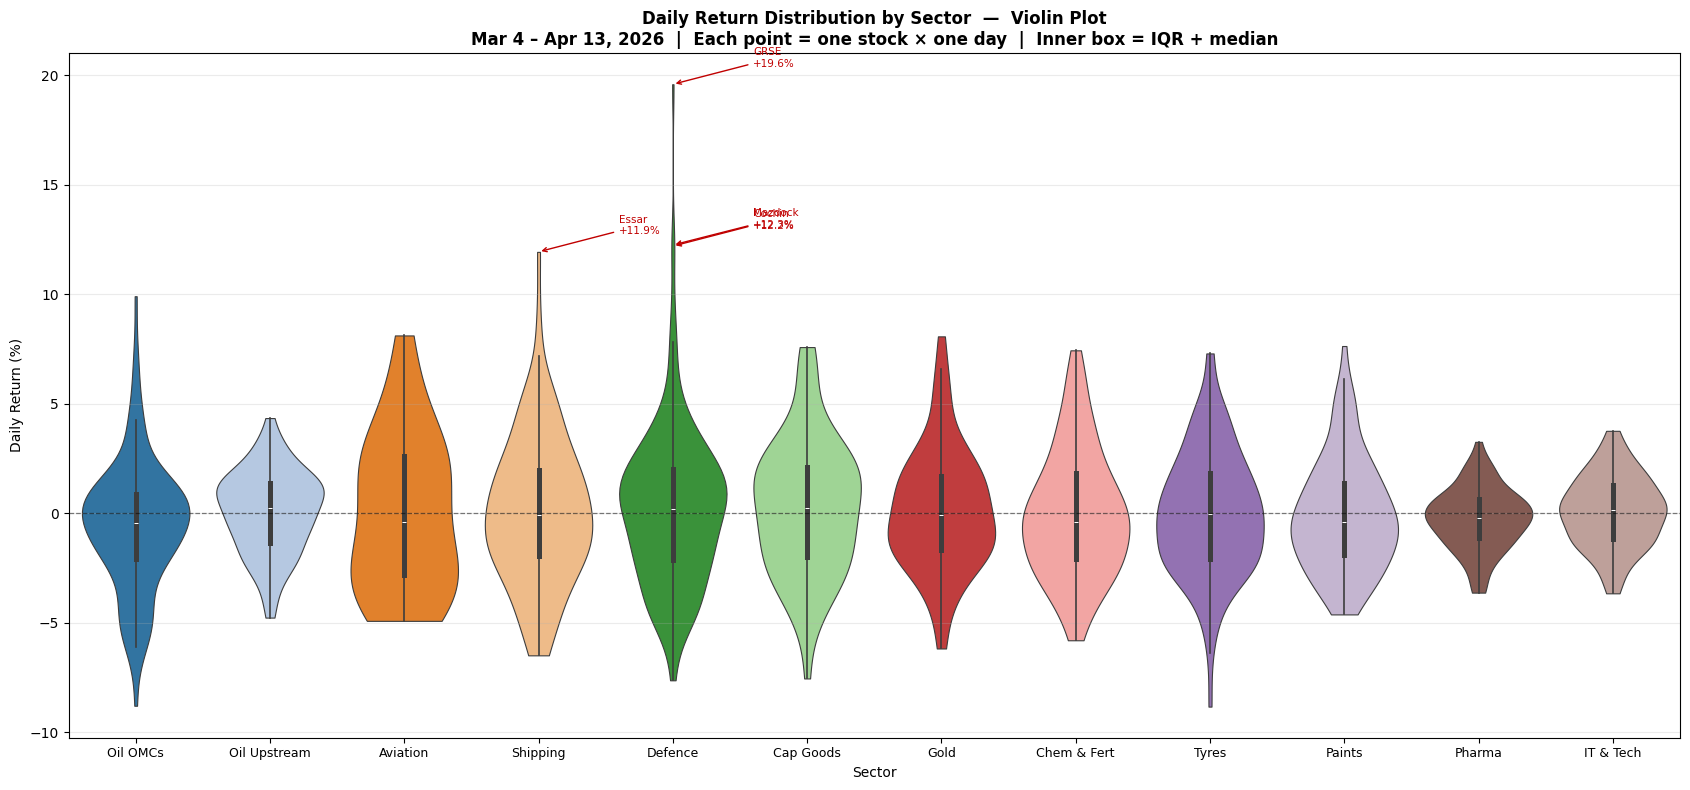

In [7]:
ret_long2 = returns.reset_index().melt(id_vars='date', var_name='ticker', value_name='ret')
ret_long2['sector'] = ret_long2['ticker'].map(TICKER_SECTOR)
ret_long2 = ret_long2.dropna(subset=['sector', 'ret'])
ret_long2['sector_short'] = ret_long2['sector'].map(SHORT_SEC)

short_order = [SHORT_SEC[s] for s in SECTOR_ORDER if s in SHORT_SEC]
palette     = {SHORT_SEC[s]: SEC_COLORS[s] for s in SECTOR_ORDER}

fig, ax = plt.subplots(figsize=(17, 8))
sns.violinplot(
    data=ret_long2,
    x='sector_short', y='ret',
    order=short_order,
    palette=palette,
    inner='box', cut=0, linewidth=0.8,
    ax=ax,
)

ax.axhline(0, color='black', linewidth=0.9, alpha=0.5, linestyle='--')

SHOCK_ANNOTS = [
    ('GRSE.NS',       '2026-04-01', 'GRSE\n+19.6%',   19.59),
    ('MAZDOCK.NS',    '2026-04-01', 'Mazdock\n+12.3%', 12.25),
    ('COCHINSHIP.NS', '2026-04-01', 'Cochin\n+12.2%',  12.20),
    ('ESSARSHPNG.NS', '2026-04-10', 'Essar\n+11.9%',   11.94),
]
for ticker, date_str, label, ret_val in SHOCK_ANNOTS:
    sec = TICKER_SECTOR.get(ticker, '')
    sec_short = SHORT_SEC.get(sec, '')
    if sec_short in short_order:
        x_pos = short_order.index(sec_short)
        ax.annotate(
            label,
            xy=(x_pos, ret_val),
            xytext=(x_pos + 0.6, ret_val + 0.8),
            fontsize=7.5, color='#c00000',
            arrowprops=dict(arrowstyle='->', color='#c00000', lw=1),
        )

ax.set_title(
    'Daily Return Distribution by Sector  \u2014  Violin Plot\n'
    'Mar 4 \u2013 Apr 13, 2026  |  Each point = one stock \u00d7 one day  |  Inner box = IQR + median',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Sector', fontsize=10)
ax.set_ylabel('Daily Return (%)', fontsize=10)
ax.tick_params(axis='x', labelsize=9)
ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('viz6_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Google Trends Visualizations — Public Anxiety During the Iran-Israel War
**3 charts from `google_trends_raw.xls`  |  28 keywords · 47 days · Feb 28 – Apr 15, 2026**  
Keywords are grouped by theme: **Geopolitical · Oil & Energy · Economy Fear · Safe Haven · Aviation**

In [8]:

# ══════════════════════════════════════════════════════════════════════════
# Google Trends — Setup  (depends on setup-code cell above)
# ══════════════════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings('ignore')

# ── Load cleaned trends (28 keywords, 47 days) ────────────────────────────
_loaded = False
for _fname in ['trends_clean.xls', 'trends_clean.csv']:
    try:
        _df = pd.read_csv(_fname)
        T = _df.set_index('date') if 'date' in _df.columns else pd.read_csv(_fname, index_col=0)
        T.index = pd.to_datetime(T.index)
        _loaded = True
        print(f'Loaded {_fname}  →  {T.shape[0]} days × {T.shape[1]} keywords')
        break
    except FileNotFoundError:
        pass

if not _loaded:
    for _fname in ['google_trends_raw.xls', 'google_trends_raw.csv']:
        try:
            T = pd.read_csv(_fname, index_col=0)
            T.index = pd.to_datetime(T.index)
            # Mirror cleaning from googletrendscleaned.ipynb
            T = T.drop(columns=T.columns[T.max() <= 10].tolist(), errors='ignore')
            _irrel = ['sensex today','nifty today','nifty prediction','stock market india',
                      'reliance share price','india gdp','import export india',
                      'best stocks to buy now','safe investment india','sell stocks now',
                      'indigo airlines','ongc share price']
            T = T.drop(columns=[c for c in _irrel if c in T.columns], errors='ignore')
            _loaded = True
            print(f'Loaded + cleaned {_fname}  →  {T.shape[0]} days × {T.shape[1]} keywords')
            break
        except FileNotFoundError:
            pass

# ── Keyword groups (same categories as googletrendsdb.ipynb) ─────────────
KEYWORD_GROUPS = {
    'Geopolitical': ['iran israel war','strait of hormuz','middle east war','world war 3',
                     'iran attack','us iran war','hormuz blockade','middle east conflict'],
    'Oil & Energy': ['oil prices','crude oil price','brent crude','oil supply shortage',
                     'energy crisis','oil price rise','diesel price india'],
    'Economy Fear': ['inflation india','recession 2026','dollar rupee','india economy war',
                     'war inflation','global recession'],
    'Safe Haven':   ['gold rate today','buy gold now','fd vs stocks','war proof investment',
                     'dollar buy india','sovereign gold bond'],
    'Aviation':     ['aviation fuel price'],
}
KEYWORD_GROUPS = {g: [k for k in kws if k in T.columns] for g, kws in KEYWORD_GROUPS.items()}

GROUP_COLORS = {
    'Geopolitical': '#d62728',
    'Oil & Energy': '#ff7f0e',
    'Economy Fear': '#9467bd',
    'Safe Haven':   '#2ca02c',
    'Aviation':     '#1f77b4',
}

# Min-max normalise each keyword 0→1 within the period → group composites for Viz T1
T_norm = (T - T.min()) / (T.max() - T.min())
G = pd.DataFrame({grp: T_norm[kws].mean(axis=1)
                  for grp, kws in KEYWORD_GROUPS.items() if kws})

# Raw group composites on trading days (Pearson r is scale-invariant) → Viz T2 & T3
_trading_days = returns.index
G_raw   = pd.DataFrame({grp: T[kws].mean(axis=1) for grp, kws in KEYWORD_GROUPS.items() if kws})
T_trade = G_raw.reindex(_trading_days)
S_trade = S.reindex(_trading_days)
kw_grp_label = {k: g for g, kws in KEYWORD_GROUPS.items() for k in kws}

print(f'Composites shape: {G.shape}  |  Trading-day subset: {T_trade.shape}')


Loaded trends_clean.xls  →  47 days × 28 keywords
Composites shape: (47, 5)  |  Trading-day subset: (26, 5)


## Viz T1 — The Anxiety Arc: How Search Attention Evolved Over the War Period
Multi-theme composite of normalised keyword trends (0 = period low, 1 = period peak per keyword).  
Reveals the *sequence* of public concern: geopolitical fear dominated and decayed early; oil/economy fear rose later; safe-haven searches were persistently elevated throughout. Dots mark each group's smoothed peak.

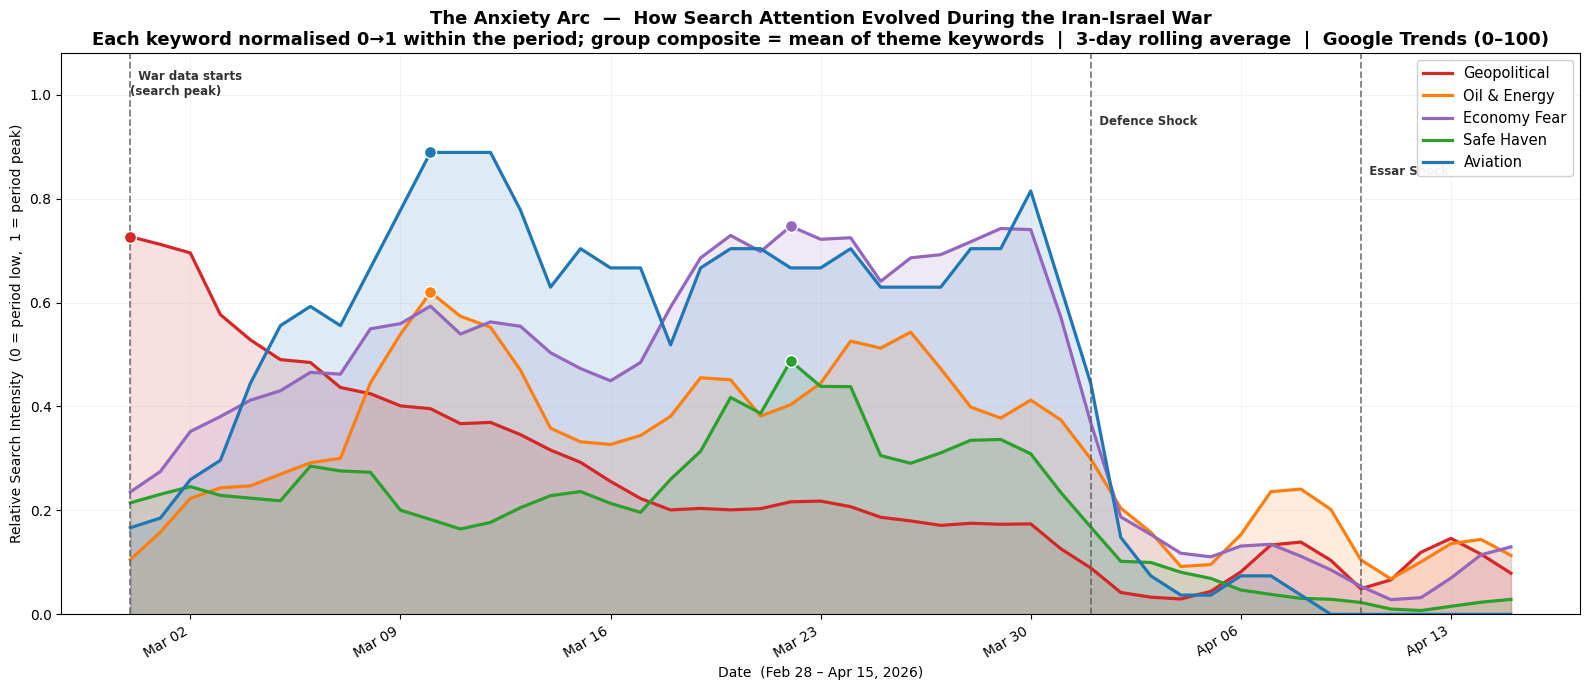

Saved: viz_t1_anxiety_arc.png


In [9]:

# ══════════════════════════════════════════════════════════════════════════
# Viz T1 — The Anxiety Arc: How Search Attention Evolved Over the War Period
# ══════════════════════════════════════════════════════════════════════════

WAR_EVENTS = {
    pd.Timestamp('2026-02-28'): ('War data starts\n(search peak)',  0.97),
    pd.Timestamp('2026-04-01'): ('Defence Shock',                   0.89),
    pd.Timestamp('2026-04-10'): ('Essar Shock',                     0.80),
}

fig, ax = plt.subplots(figsize=(16, 7))

for grp in ['Geopolitical','Oil & Energy','Economy Fear','Safe Haven','Aviation']:
    if grp not in G.columns: continue
    s = G[grp].rolling(3, center=True, min_periods=1).mean()
    c = GROUP_COLORS[grp]
    ax.fill_between(G.index, s, alpha=0.14, color=c)
    ax.plot(G.index, s, color=c, linewidth=2.3, label=grp)
    # Mark smoothed peak
    _pk_dt  = s.idxmax()
    _pk_val = float(s.max())
    ax.scatter([_pk_dt], [_pk_val], color=c, s=75, zorder=5,
               edgecolors='white', linewidths=1.0)

# Event annotations
for dt, (lbl, ypos) in WAR_EVENTS.items():
    ax.axvline(dt, color='#555', linestyle='--', linewidth=1.3, alpha=0.75)
    ax.text(dt, ypos, f'  {lbl}', fontsize=8.5, color='#333', va='top',
            transform=ax.get_xaxis_transform(), fontweight='bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

ax.set_title(
    'The Anxiety Arc  —  How Search Attention Evolved During the Iran-Israel War\n'
    'Each keyword normalised 0→1 within the period; group composite = mean of theme keywords  |  '
    '3-day rolling average  |  Google Trends (0–100)',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('Relative Search Intensity  (0 = period low,  1 = period peak)', fontsize=10)
ax.set_xlabel('Date  (Feb 28 – Apr 15, 2026)', fontsize=10)
ax.legend(loc='upper right', fontsize=10.5, framealpha=0.93)
ax.set_ylim(0, 1.08)
ax.grid(True, alpha=0.2, linewidth=0.5)

plt.tight_layout()
plt.savefig('viz_t1_anxiety_arc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_t1_anxiety_arc.png')


## Viz T2 — Keyword Peak Cascade: When Did Each Search Term Hit Maximum Interest?
Timeline showing the date of peak search interest for all 28 keywords, sorted chronologically.  
Reveals which fears came *first* (geopolitical), which peaked *later* (economy/safe-haven), and which were triggered by specific market events. Dot size = peak Google Trends score (0–100).

In [ ]:

# ══════════════════════════════════════════════════════════════════════════
# Viz T2 — Keyword Peak Cascade: When Did Each Search Term Peak?
# ══════════════════════════════════════════════════════════════════════════
from matplotlib.patches import Patch

_peak_rows = []
for kw in T.columns:
    _peak_rows.append({
        'keyword':    kw,
        'peak_date':  T[kw].idxmax(),
        'peak_val':   int(T[kw].max()),
        'group':      kw_grp_label.get(kw, 'Other'),
    })
peak_df = pd.DataFrame(_peak_rows).sort_values('peak_date').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(15, 10))

for i, row in peak_df.iterrows():
    c  = GROUP_COLORS.get(row['group'], '#888')
    _s = max(20, row['peak_val'] * 2.8)   # dot size ∝ peak intensity
    ax.hlines(i, T.index.min(), row['peak_date'],
              color=c, alpha=0.22, linewidth=1.1, zorder=1)
    ax.scatter(row['peak_date'], i, color=c, s=_s, alpha=0.88, zorder=5,
               edgecolors='white', linewidths=0.8)
    ax.text(row['peak_date'] + pd.Timedelta(days=0.8), i,
            str(row['peak_val']), fontsize=6.8, va='center', color=c, alpha=0.9)

# Market event lines
for dt, lbl in {pd.Timestamp('2026-04-01'): 'Defence Shock',
                pd.Timestamp('2026-04-10'): 'Essar Shock'}.items():
    ax.axvline(dt, color='#888', linestyle='--', linewidth=1.2, alpha=0.75)
    ax.text(dt, -0.7, f'  {lbl}', fontsize=8.5, color='#444', va='top',
            transform=ax.get_xaxis_transform(), fontweight='bold')

# Y-axis: keyword labels coloured by group, earliest at top
ax.set_yticks(range(len(peak_df)))
ax.set_yticklabels(peak_df['keyword'], fontsize=8.5)
ax.invert_yaxis()
for lbl, (_, row) in zip(ax.get_yticklabels(), peak_df.iterrows()):
    lbl.set_color(GROUP_COLORS.get(row['group'], 'black'))
    lbl.set_fontweight('bold')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_xlim(T.index.min() - pd.Timedelta(days=2),
            T.index.max() + pd.Timedelta(days=6))

_leg = [Patch(facecolor=GROUP_COLORS[g], label=g)
        for g in ['Geopolitical','Oil & Energy','Economy Fear','Safe Haven','Aviation']]
ax.legend(handles=_leg, title='Search Theme', loc='lower right',
          fontsize=9, title_fontsize=9.5, framealpha=0.92)
ax.grid(True, axis='x', alpha=0.18, linewidth=0.5)
ax.set_title(
    'Keyword Peak Cascade  —  When Did Each Search Term Hit Maximum Interest?\n'
    'Dot = date of peak (sized by Google Trends score 0–100)  |  '
    'Line = period start → peak  |  Sorted top-to-bottom by peak date',
    fontsize=12.5, fontweight='bold'
)
ax.set_xlabel('Date  (Feb 28 – Apr 15, 2026)', fontsize=10)
plt.tight_layout()
plt.savefig('viz_t2_keyword_peak_cascade.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_t2_keyword_peak_cascade.png')


## Viz T3 — Did Google Trends Predict Markets? Lead-Lag Correlation Analysis
**Left**: Same-day (Lag 0) — coincident correlation between search theme and sector return.  
**Right**: Predictive lift (Lag+1 − Lag 0) — positive Δr means the search theme today had *extra* predictive power for tomorrow's return, beyond what same-day correlation captures.  
A strongly positive Δr in the right panel = a *tradeable signal*.

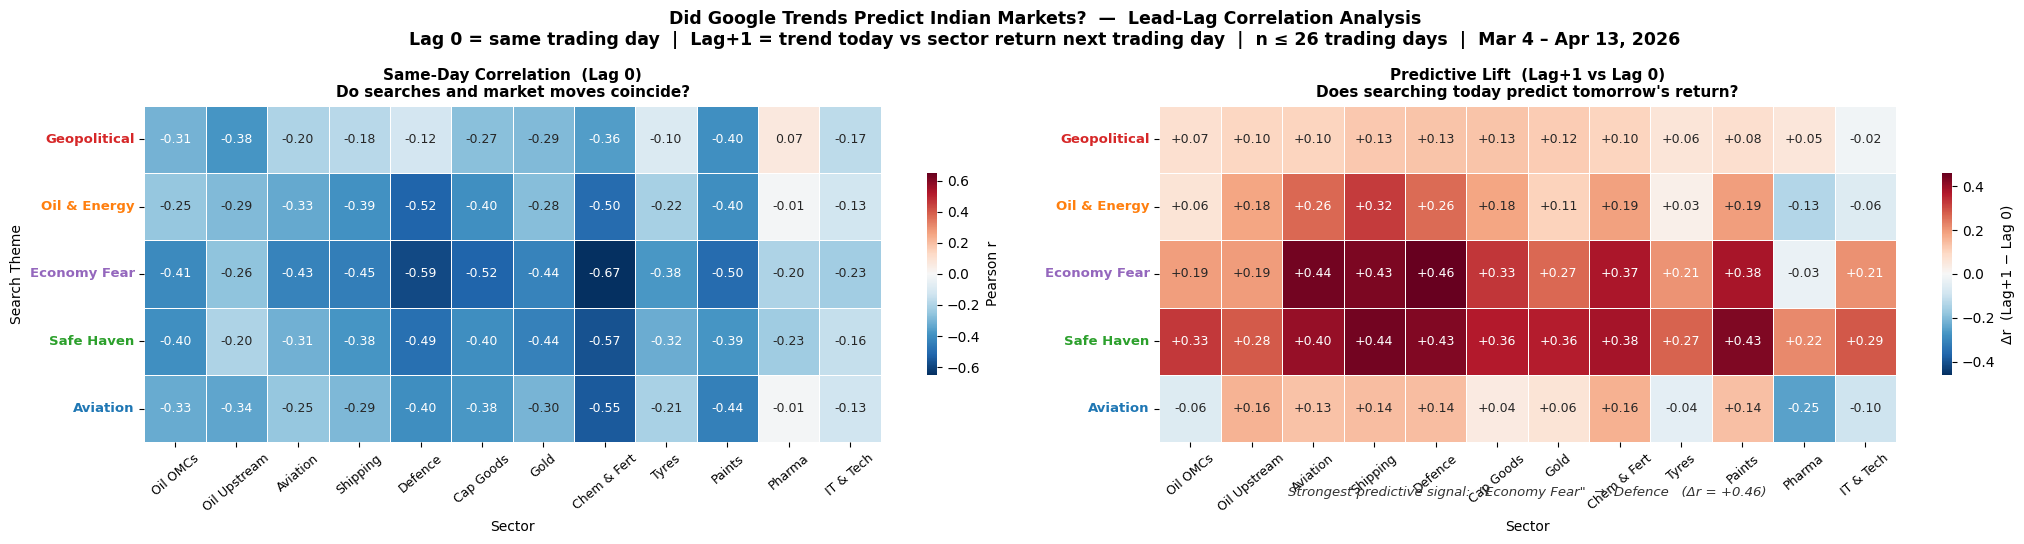

Saved: viz_t3_leadlag_analysis.png


In [11]:

# ══════════════════════════════════════════════════════════════════════════
# Viz T3 — Did Google Trends Predict Markets? Lead-Lag Correlation
# ══════════════════════════════════════════════════════════════════════════

def _lag_corr(t, r, lag):
    """Pearson r between t and r at trading-day offset `lag`. Positive = trend leads market."""
    n = min(len(t), len(r)); t, r = t[:n], r[:n]
    if lag == 0:    return float(np.corrcoef(t, r)[0, 1])
    if lag > 0  and lag < n: return float(np.corrcoef(t[:-lag],    r[lag:]   )[0, 1])
    if lag < 0  and abs(lag) < n: return float(np.corrcoef(t[abs(lag):], r[:-abs(lag)])[0, 1])
    return np.nan

_grp_t3 = [g for g in ['Geopolitical','Oil & Energy','Economy Fear','Safe Haven','Aviation']
           if g in T_trade.columns]
_sec_t3  = [s for s in SECTOR_ORDER if s in S.columns]
_sho_t3  = [SHORT_SEC[s] for s in _sec_t3]

def _build_lag_mat(lag):
    mat = pd.DataFrame(index=_grp_t3, columns=_sho_t3, dtype=float)
    for grp in _grp_t3:
        ts = T_trade[grp].dropna()
        for sec, sho in zip(_sec_t3, _sho_t3):
            rs = S_trade[sec].dropna()
            idx = ts.index.intersection(rs.index)
            mat.loc[grp, sho] = _lag_corr(ts.loc[idx].values, rs.loc[idx].values, lag)
    return mat.astype(float)

lag0_mat = _build_lag_mat(0)
lag1_mat = _build_lag_mat(1)
lift_mat  = lag1_mat - lag0_mat   # positive Δr = trend has predictive power beyond coincidence

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(21, 5.5))

# Left: Same-day (Lag 0)
sns.heatmap(lag0_mat, ax=ax1, cmap='RdBu_r', center=0, vmin=-0.65, vmax=0.65,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Pearson r', 'shrink': 0.6})
ax1.set_title('Same-Day Correlation  (Lag 0)\nDo searches and market moves coincide?',
              fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', rotation=40, labelsize=9)
ax1.tick_params(axis='y', labelsize=9.5, rotation=0)
ax1.set_xlabel('Sector', fontsize=10)
ax1.set_ylabel('Search Theme', fontsize=10)
for lbl in ax1.get_yticklabels():
    lbl.set_color(GROUP_COLORS.get(lbl.get_text(), 'black'))
    lbl.set_fontweight('bold')

# Right: Predictive lift (Lag+1 − Lag 0)
_vmax_l = max(abs(float(np.nanmin(lift_mat.values))), abs(float(np.nanmax(lift_mat.values))), 0.01)
sns.heatmap(lift_mat, ax=ax2, cmap='RdBu_r', center=0, vmin=-_vmax_l, vmax=_vmax_l,
            annot=True, fmt='+.2f', annot_kws={'size': 9},
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Δr  (Lag+1 − Lag 0)', 'shrink': 0.6})
ax2.set_title("Predictive Lift  (Lag+1 vs Lag 0)\nDoes searching today predict tomorrow's return?",
              fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=40, labelsize=9)
ax2.tick_params(axis='y', labelsize=9.5, rotation=0)
ax2.set_xlabel('Sector', fontsize=10)
ax2.set_ylabel('')
for lbl in ax2.get_yticklabels():
    lbl.set_color(GROUP_COLORS.get(lbl.get_text(), 'black'))
    lbl.set_fontweight('bold')

# Call out strongest predictive signal
try:
    _li = lift_mat.abs().stack()
    _bg, _bs = _li.idxmax()
    _bv = float(lift_mat.loc[_bg, _bs])
    ax2.text(0.5, -0.16,
             f'Strongest predictive signal:  "{_bg}"  →  {_bs}   (Δr = {_bv:+.2f})',
             ha='center', fontsize=9.5, transform=ax2.transAxes,
             style='italic', color='#333333')
except Exception:
    pass

fig.suptitle(
    'Did Google Trends Predict Indian Markets?  —  Lead-Lag Correlation Analysis\n'
    'Lag 0 = same trading day  |  Lag+1 = trend today vs sector return next trading day  |  '
    'n ≤ 26 trading days  |  Mar 4 – Apr 13, 2026',
    fontsize=12.5, fontweight='bold'
)
plt.tight_layout()
plt.savefig('viz_t3_leadlag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_t3_leadlag_analysis.png')
